In [1]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
from typing import Tuple, Union
import math
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
MARGIN = 10  # pixels
ROW_SIZE = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
TEXT_COLOR = (255, 0, 0)  # red


def _normalized_to_pixel_coordinates(
    normalized_x: float, normalized_y: float, image_width: int,
    image_height: int) -> Union[None, Tuple[int, int]]:
  """Converts normalized value pair to pixel coordinates."""

  # Checks if the float value is between 0 and 1.
  def is_valid_normalized_value(value: float) -> bool:
    return (value > 0 or math.isclose(0, value)) and (value < 1 or
                                                      math.isclose(1, value))

  if not (is_valid_normalized_value(normalized_x) and
          is_valid_normalized_value(normalized_y)):
    # TODO: Draw coordinates even if it's outside of the image bounds.
    return None
  x_px = min(math.floor(normalized_x * image_width), image_width - 1)
  y_px = min(math.floor(normalized_y * image_height), image_height - 1)
  return x_px, y_px


def visualize(
    image,
    detection_result
) -> np.ndarray:
  """Draws bounding boxes and keypoints on the input image and return it.
  Args:
    image: The input RGB image.
    detection_result: The list of all "Detection" entities to be visualize.
  Returns:
    Image with bounding boxes.
  """
  annotated_image = image.copy()
  height, width, _ = image.shape

  coords = []

  for detection in detection_result.detections:
    # Draw bounding_box
    bbox = detection.bounding_box
    start_point = bbox.origin_x, bbox.origin_y
    end_point = bbox.origin_x + bbox.width, bbox.origin_y + bbox.height
    coords.append(bbox.origin_x) #0
    coords.append(bbox.origin_y) #1
    coords.append(bbox.width) #2
    coords.append(bbox.height) #3
    cv2.rectangle(annotated_image, start_point, end_point, TEXT_COLOR, 3)
  
  cropped_image = annotated_image[coords[1]:coords[1]+coords[3],
                                  coords[0]:coords[0]+coords[2]]

  return cropped_image

In [19]:
# base_options = python.BaseOptions(model_asset_path='/home/nikita/Downloads/blaze_face_full_range.tflite')
# options = vision.FaceDetectorOptions(base_options=base_options)
# detector = vision.FaceDetector.create_from_options(options)

# # STEP 3: Load the input image.
# image = mp.Image.create_from_file('/home/nikita/Pictures/Camera/Photo from 2026-04-30 15-55-45.211371.jpeg')

# # STEP 4: Detect faces in the input image.
# detection_result = detector.detect(image)

# # STEP 5: Process the detection result. In this case, visualize it.
# image_copy = np.copy(image.numpy_view())
# annotated_image = visualize(image_copy, detection_result)

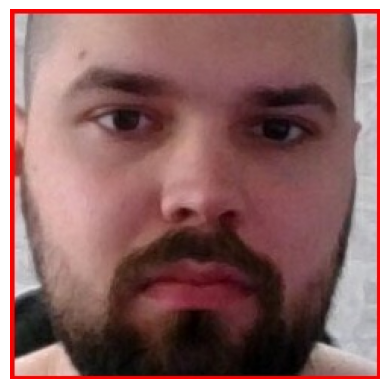

In [ ]:
# rgb_annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
# cv2.imwrite('test.jpg', rgb_annotated_image)
# img = cv2.imread('test.jpg')
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()

In [18]:
IMAGES_FOLDER = Path('/home/nikita/Pictures/Camera')
base_options = python.BaseOptions(model_asset_path='/home/nikita/Downloads/blaze_face_full_range.tflite')
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)
DESTINY_FOLDER = '/home/nikita/faceRecognition/my_face_dataset'

for photo in IMAGES_FOLDER.iterdir():
    image = mp.Image.create_from_file(f'{photo}')
    detection_result = detector.detect(image)
    image_copy = np.copy(image.numpy_view())
    annotated_image = visualize(image_copy, detection_result)

    rgb_annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    full_path = os.path.join(DESTINY_FOLDER, f'cropped_{photo.name}.jpg')

    cv2.imwrite(full_path, rgb_annotated_image)

I0000 00:00:1777557877.587205  601741 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777557877.589871  601759 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.6), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1777557877.598064  601746 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
